In [1]:
import pandas as pd
import numpy as np
import mglearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
#偏ったデータセットを作ってみる
from sklearn.datasets import load_digits
digits = load_digits()
y = digits.target == 9

x_train, x_test, y_train, y_test = train_test_split(
    digits.data, 
    y,
    random_state=42
)

In [ ]:
#DummyClassifierを常に多数のクラス(ここでは「９以外」)を予測するようにして、精度が役に立たないことを確かめてみる
from sklearn.dummy import DummyClassifier
dummy_majority = DummyClassifier(strategy="most_frequent").fit(x_train, y_train)
pred_most_frequent = dummy_majority.predict(x_test)

#すべてを９以外と予測しても、精度は高くなることがわかる
#しかし、これは役に立たないモデルであることがわかる
print("Unique predicted labels:{}".format(np.unique(pred_most_frequent)))
print("Test score:{:.2f}".format(dummy_majority.score(x_test, y_test)))

Unique predicted labels:[False]
Test score:0.89


In [ ]:
#実際のクラス分類器と比較してみる
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=2).fit(x_train, y_train)
pred_tree = tree.predict(x_test)

#常に同じ答えを返す予測器よりも少しいいだけ
#これはDecisionTreeClassifierの使い方を何か間違えたか、精度が良い基準でないかのどちらか
print("Unique predicted labels (Tree):{}".format(np.unique(pred_tree)))
print("Test score (Tree):{:.2f}".format(tree.score(x_test, y_test)))

Unique predicted labels (Tree):[False  True]
Test score (Tree):0.92


In [12]:
#あと二つのクラス分類器を比較してみる
from sklearn.linear_model import LogisticRegression

#完全ランダムに予測
dummy = DummyClassifier( strategy="stratified",random_state=0).fit(x_train, y_train)
pred_dummy = dummy.predict(x_test)
print("Test score (Dummy):{:.2f}".format(dummy.score(x_test, y_test)))

logreg = LogisticRegression(C=0.1).fit(x_train,y_train)
pred_logreg = logreg.predict(x_test)
print("Test score (Logistic Regression):{:.2f}".format(logreg.score(x_test, y_test)))

Test score (Dummy):0.80
Test score (Logistic Regression):0.98


c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
#混合行列を使ってみる
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(
    y_test,
    pred_logreg
)

print("Confusion matrix:\n{}".format(confusion))

Confusion matrix:
[[399   3]
 [  5  43]]


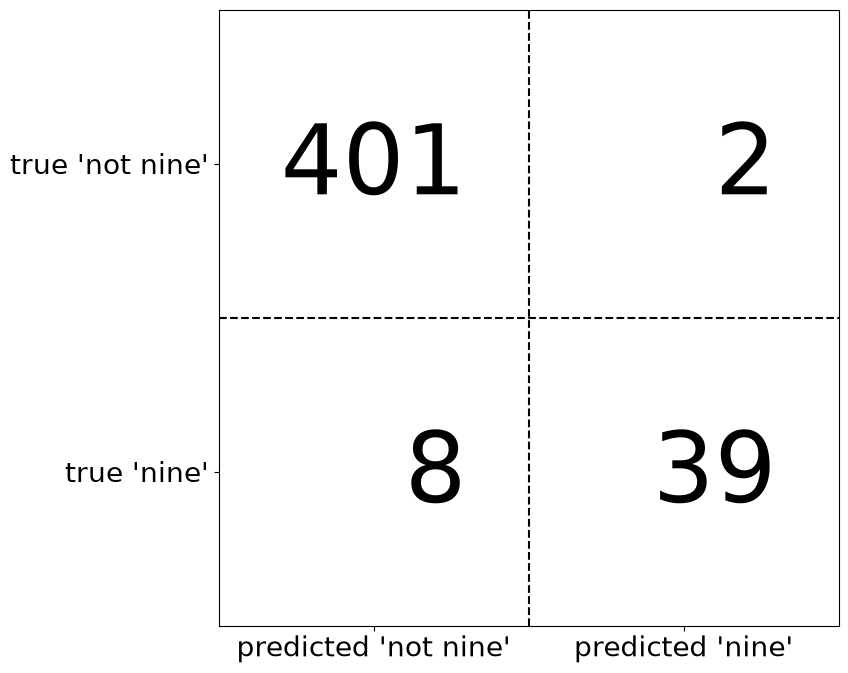

In [14]:
#混合行列の意味を視覚的に確認
mglearn.plots.plot_confusion_matrix_illustration()

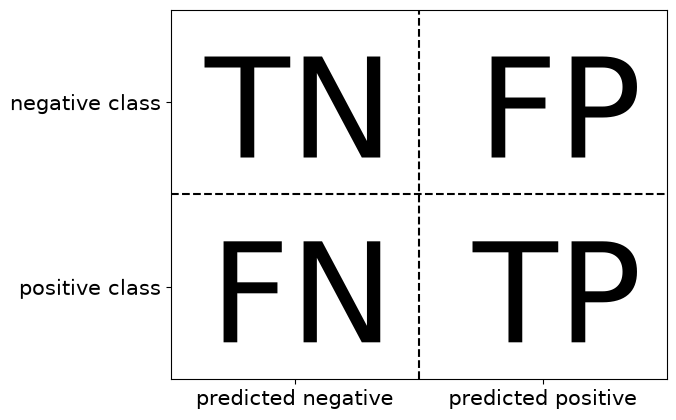

In [15]:
mglearn.plots.plot_binary_confusion_matrix()

In [ ]:
print("Most frequent class")
print(confusion_matrix(y_test, pred_most_frequent))
print("\nDummy model")
print(confusion_matrix(y_test, pred_dummy))
print("\nDecision tree")
print(confusion_matrix(y_test, pred_tree))
print("\nLogistic regression")
print(confusion_matrix(y_test, pred_logreg))

Most frequent class
[[402   0]
 [ 48   0]]

Dummy model
[[357  45]
 [ 43   5]]

Decision tree
[[376  26]
 [ 12  36]]

Logistic regression
[[399   3]
 [  5  43]]


## 精度（Accuracy）

全予測のうち、正しく分類できた割合。

$$
\mathrm{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}
$$

## 適合率（Precision）

陽性と予測したもののうち、実際に陽性だった割合。
偽陽性（FP）を減らしたい場合に重視する。

$$
\mathrm{Precision} = \frac{TP}{TP+FP}
$$

## 再現率（Recall）

実際に陽性であるもののうち、正しく陽性と予測できた割合。
偽陰性（FN）、つまり見逃しを減らしたい場合に重視する。

$$
\mathrm{Recall} = \frac{TP}{TP+FN}
$$

## F1値（F1-score）

適合率と再現率の調和平均。
どちらか一方が低い場合、F1値も低くなる。

$$
F_1 = 2\frac{\mathrm{Precision}\cdot\mathrm{Recall}}{\mathrm{Precision}+\mathrm{Recall}}
$$

In [18]:
#f1スコアで比較してみる
from sklearn.metrics import f1_score

print("f1 score most frequent: {:.2f}".format(f1_score(y_test, pred_most_frequent)))
print("f1 score dummy: {:.2f}".format(f1_score(y_test, pred_dummy)))
print("f1 score tree: {:.2f}".format(f1_score(y_test, pred_tree)))
print("f1 score logistic regression: {:.2f}".format(f1_score(y_test, pred_logreg)))

f1 score most frequent: 0.00
f1 score dummy: 0.10
f1 score tree: 0.65
f1 score logistic regression: 0.91


In [23]:
#classification_reportを使ってみると、適合率、再現率、f1スコアをまとめて確認できる

from sklearn.metrics import classification_report
print(classification_report(y_test, pred_most_frequent, target_names=["Not 9", "9"]))


              precision    recall  f1-score   support

       Not 9       0.89      1.00      0.94       402
           9       0.00      0.00      0.00        48

    accuracy                           0.89       450
   macro avg       0.45      0.50      0.47       450
weighted avg       0.80      0.89      0.84       450



c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [28]:
#ダミークラス分類器の結果を確認してみる
print(classification_report(y_test, pred_dummy, target_names=["Not 9", "9"]))

              precision    recall  f1-score   support

       Not 9       0.89      0.89      0.89       402
           9       0.10      0.10      0.10        48

    accuracy                           0.80       450
   macro avg       0.50      0.50      0.50       450
weighted avg       0.81      0.80      0.81       450



In [24]:
#ロジスティック回帰でも確認
print(classification_report(y_test, pred_logreg, target_names=["Not 9", "9"]))

              precision    recall  f1-score   support

       Not 9       0.99      0.99      0.99       402
           9       0.93      0.90      0.91        48

    accuracy                           0.98       450
   macro avg       0.96      0.94      0.95       450
weighted avg       0.98      0.98      0.98       450



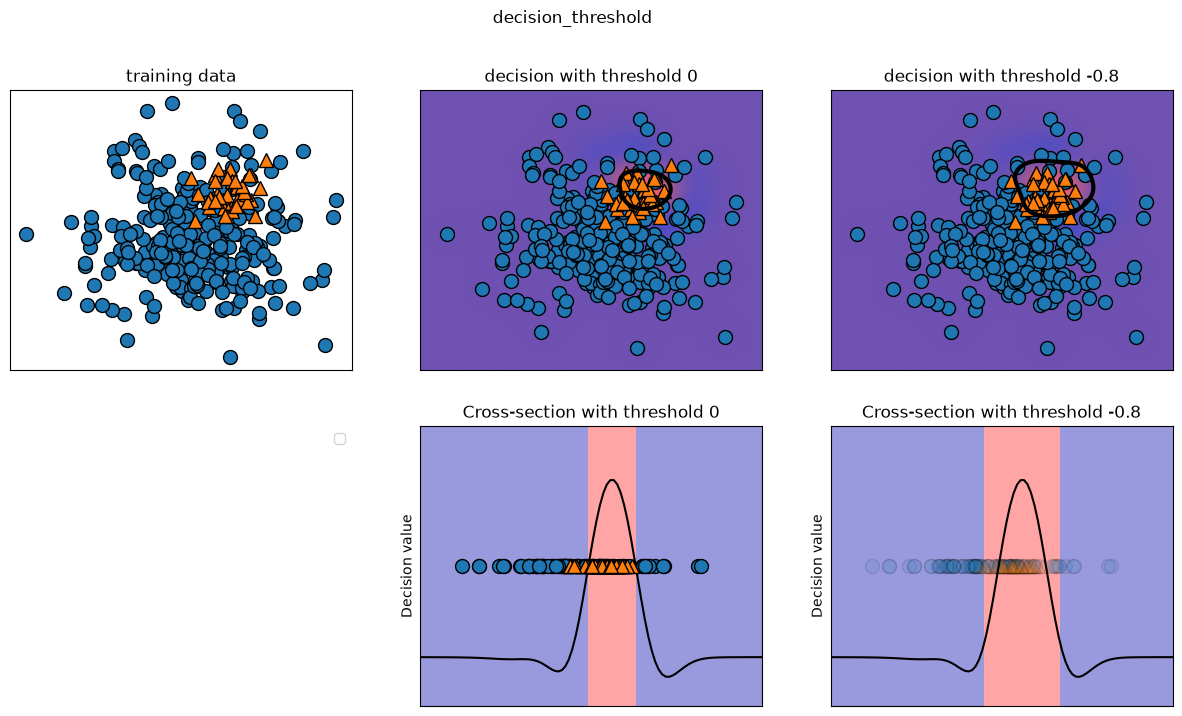

In [ ]:
#決定関数の閾値を変えてプロット

from mglearn.datasets import make_blobs
from sklearn.svm import SVC
X, y = make_blobs(n_samples=(400, 50),
                  cluster_std=[7.0, 2],
                  random_state=22
                )
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
svc = SVC(gamma=.05).fit(X_train, y_train)

mglearn.plots.plot_decision_threshold()
plt.show()

In [32]:
#classification_reportを使って確認
print(classification_report(y_test, svc.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      0.89      0.93       104
           1       0.35      0.67      0.46         9

    accuracy                           0.88       113
   macro avg       0.66      0.78      0.70       113
weighted avg       0.92      0.88      0.89       113



In [ ]:
#スレッショルドを小さくしてみる
#ほんとはテストデータを使ってスレッショルドを設定してはいけない

y_pred_lower_threshold = svc.decision_function(X_test) > -.8
print(classification_report(y_test, y_pred_lower_threshold))

              precision    recall  f1-score   support

           0       1.00      0.82      0.90       104
           1       0.32      1.00      0.49         9

    accuracy                           0.83       113
   macro avg       0.66      0.91      0.69       113
weighted avg       0.95      0.83      0.87       113



In [ ]:
#predict_probaを使った方が直感的である
#だが、全てのクラス分類器がpredict_probaをサポートしているわけではない
#CalibratedClassifierCVを使って較正したモデルは、確信度に対して正確な基準を提供するので、
#確率を出せない分類器に確率推定機能を追加する用途にも使える。

- 適合率-再現率カーブ

In [36]:
#モデルの問題をよりよく理解するためには、全ての可能なスレッショルド、すなわち
#すべての可能な適合率と再現率の組み合わせを同時に見ることが役に立つ
#これには、適合率、再現率カーブが役に立つ

from sklearn.metrics import precision_recall_curve

precision,recall,thresholds = precision_recall_curve(
    y_test,
    svc.decision_function(X_test)
)


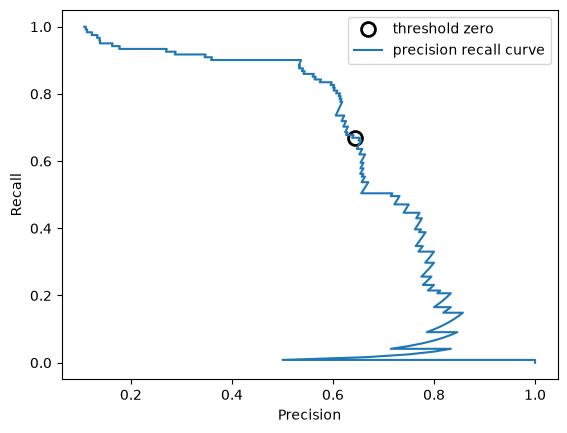

In [38]:
X, y = make_blobs(n_samples=(4000, 500),cluster_std=[7.0, 2], random_state=22)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
svc = SVC(gamma=.05).fit(X_train, y_train)
precision, recall, thresholds = precision_recall_curve(y_test, svc.decision_function(X_test))

close_zero = np.argmin(np.abs(thresholds))
plt.plot(precision[close_zero], recall[close_zero], 'o', markersize=10,
         label="threshold zero", fillstyle="none", c='k', mew=2)

plt.plot(precision, recall, label="precision recall curve")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.legend(loc="best")
plt.show()

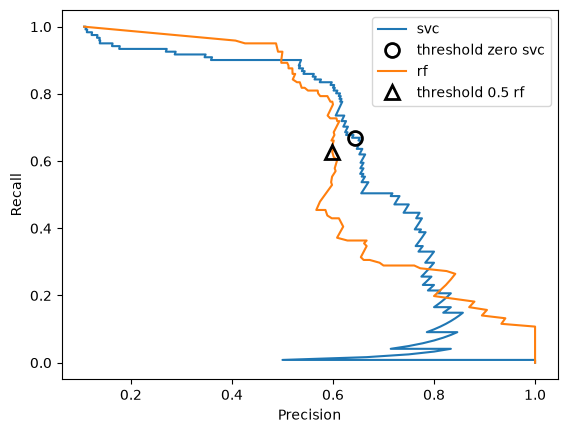

In [ ]:
#SVCの結果とランダムフォレストの結果を比較してみる
#precision_recall_curveの第二引数は、陽性クラス(クラス１)の確信度尺度

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=0, max_features=2)
rf.fit(X_train, y_train)

precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, rf.predict_proba(X_test)[:, 1])

plt.plot(precision, recall, label="svc")

plt.plot(precision[close_zero], recall[close_zero], 'o', markersize=10, label="threshold zero svc", fillstyle="none", c='k', mew=2)

plt.plot(precision_rf, recall_rf, label="rf")

close_default_rf = np.argmin(np.abs(thresholds_rf - 0.5))
plt.plot(precision_rf[close_default_rf], recall_rf[close_default_rf], '^', c='k', markersize=10, label="threshold 0.5 rf", fillstyle="none", mew=2)
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.legend(loc="best")
plt.show()

In [40]:
#F1スコアだけを見ていては、上図のような微妙な部分を見過ごしてしまう
print("f1_score of random forest: {:.3f}".format(f1_score(y_test, rf.predict(X_test))))
print("f1_score of svc: {:.3f}".format(f1_score(y_test, svc.predict(X_test))))

f1_score of random forest: 0.610
f1_score of svc: 0.656


In [41]:
#適合率-再現率カーブを要約する方法の一つが、カーブの下の領域を積分する方法で、これは平均適合率(average precision)と呼ばれる
from sklearn.metrics import average_precision_score
ap_rf = average_precision_score(y_test, rf.predict_proba(X_test)[:, 1])
ap_svc = average_precision_score(y_test, svc.decision_function(X_test))
print("Average precision of random forest: {:.3f}".format(ap_rf))
print("Average precision of svc: {:.3f}".format(ap_svc))

Average precision of random forest: 0.660
Average precision of svc: 0.666


- ROC曲線

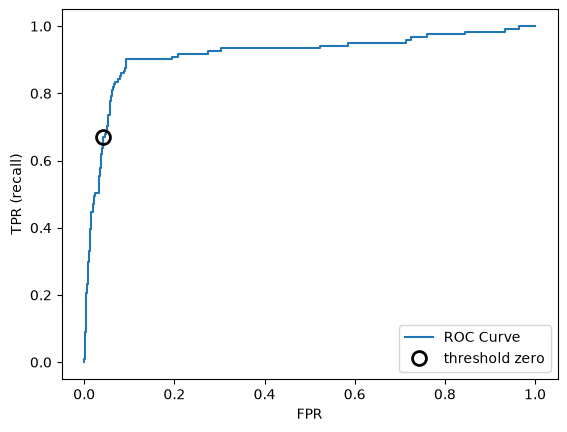

In [ ]:
#ROC曲線（Receiver Operating Characteristic Curve）
# ・分類の閾値を変化させたときの偽陽性率（FPR）と真陽性率（TPR）の関係を表す
# ・横軸：偽陽性率（FPR）＝ FP / (FP + TN)
# ・縦軸：真陽性率（TPR）＝ TP / (TP + FN)（再現率と同じ）
# ・曲線が左上に近いほど、陽性と陰性を区別する性能が高い
# ・対角線はランダムな予測に相当する
# ・AUCはROC曲線の下の面積で、1に近いほど識別性能が高い
# ・クラスが不均衡な場合は、PR曲線も確認することが重要

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, svc.decision_function(X_test))

plt.plot(fpr, tpr, label="ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR (recall)")
#0に最も近いスレッショルドの点をプロット
close_zero = np.argmin(np.abs(thresholds))
plt.plot(fpr[close_zero], tpr[close_zero], 'o', markersize=10,label="threshold zero", fillstyle="none", c='k', mew=2)
plt.legend(loc=4)
plt.show()

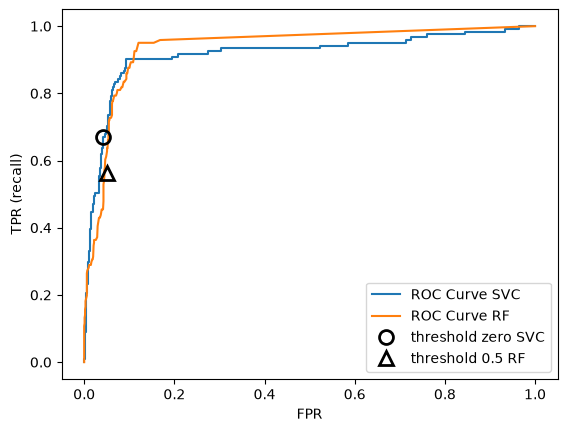

In [43]:
#ランダムフォレストとSVCのROC曲線を比較

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])

plt.plot(fpr, tpr, label="ROC Curve SVC")
plt.plot(fpr_rf, tpr_rf, label="ROC Curve RF")

plt.xlabel("FPR")
plt.ylabel("TPR (recall)")
plt.plot(fpr[close_zero], tpr[close_zero], 'o', markersize=10, label="threshold zero SVC", fillstyle="none", c='k', mew=2)
close_default_rf = np.argmin(np.abs(thresholds_rf - 0.5))
plt.plot(fpr_rf[close_default_rf], tpr[close_default_rf], '^', markersize=10, label="threshold 0.5 RF", fillstyle="none", c='k', mew=2)

plt.legend(loc=4)
plt.show()

In [45]:
#カーブ下の領域面積を用いてROCカーブを一つの値にまとめる
from sklearn.metrics import roc_auc_score

auc_svc = roc_auc_score(y_test, svc.decision_function(X_test))
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
print("AUC of SVC: {:.3f}".format(auc_svc))
print("AUC of Random Forest: {:.3f}".format(auc_rf))

AUC of SVC: 0.916
AUC of Random Forest: 0.937


gamma = 1.00  accuracy = 0.90  AUC = 0.50
gamma = 0.05  accuracy = 0.90  AUC = 1.00
gamma = 0.01  accuracy = 0.90  AUC = 1.00


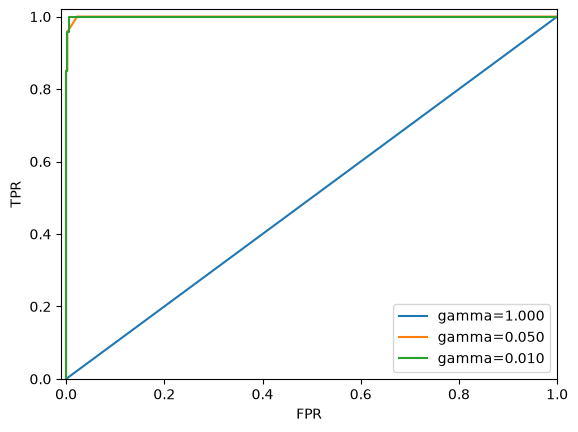

In [ ]:
y = digits.target == 9

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, y, random_state=0)

plt.figure()


#AUC = 1ということは、FPR = 0、TPR = 1であり、うまく設定すれば完全に陽性と陰性を区別できることを意味する

for gamma in [1, 0.05, 0.01]:
    svc = SVC(gamma=gamma).fit(X_train, y_train)
    accuracy = svc.score(X_test, y_test)
    auc = roc_auc_score(y_test, svc.decision_function(X_test))
    fpr, tpr, _ = roc_curve(y_test , svc.decision_function(X_test))
    print("gamma = {:.2f}  accuracy = {:.2f}  AUC = {:.2f}".format(gamma, accuracy, auc))
    plt.plot(fpr, tpr, label="gamma={:.3f}".format(gamma))
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.xlim(-0.01, 1)
plt.ylim(0, 1.02)
plt.legend(loc="best")
plt.show()

In [ ]:
# 分類モデルはAccuracy、ROC-AUC、PR-AUCなどを用いて多角的に評価する
# ただし、データの不均衡や目的によって重視する指標は異なる
# 実際の運用では、閾値を決めた上で適合率・再現率なども確認する

- 多クラス分類の基準

In [47]:
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, random_state=0)
lr = LogisticRegression().fit(X_train, y_train)
pred = lr.predict(X_test)
print("Accuracy: {:.3f}".format(accuracy_score(y_test, pred)))
print("Confusion matrix:\n{}".format(confusion_matrix(y_test, pred)))

Accuracy: 0.951
Confusion matrix:
[[37  0  0  0  0  0  0  0  0  0]
 [ 0 40  0  0  0  0  0  0  2  1]
 [ 0  1 40  3  0  0  0  0  0  0]
 [ 0  0  0 43  0  0  0  0  1  1]
 [ 0  0  0  0 37  0  0  1  0  0]
 [ 0  0  0  0  0 46  0  0  0  2]
 [ 0  1  0  0  0  0 51  0  0  0]
 [ 0  0  0  1  1  0  0 46  0  0]
 [ 0  3  1  0  0  0  0  0 43  1]
 [ 0  0  0  0  0  1  0  0  1 45]]


c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


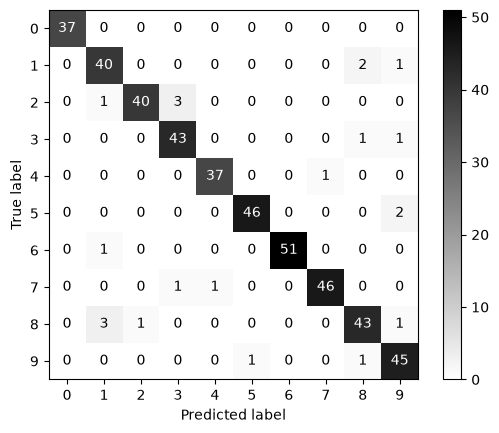

In [ ]:
#混同行列を表示するための ConfusionMatrixDisplayを使用
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=digits.target_names,
    cmap=plt.cm.gray_r,
    values_format="d"
)

plt.show()

In [54]:
#Classification report関数を使用して、適合率、再現率、f1スコアをまとめて確認する
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       0.89      0.93      0.91        43
           2       0.98      0.91      0.94        44
           3       0.91      0.96      0.93        45
           4       0.97      0.97      0.97        38
           5       0.98      0.96      0.97        48
           6       1.00      0.98      0.99        52
           7       0.98      0.96      0.97        48
           8       0.91      0.90      0.91        48
           9       0.90      0.96      0.93        47

    accuracy                           0.95       450
   macro avg       0.95      0.95      0.95       450
weighted avg       0.95      0.95      0.95       450



In [ ]:
# 多クラス分類のF1値
# ・各クラスを陽性、それ以外を陰性とみなしてF1値を計算する
# ・F1値は適合率と再現率の調和平均
# ・macro：各クラスのF1値を単純平均する（クラスを平等に評価）
# ・weighted：各クラスのF1値をデータ数で重み付けして平均する
# ・micro：全クラスのTP、FP、FNを合計してF1値を計算する(個々のサンプルを平等に評価)
# ・不均衡データではmacroとweightedの違いに注意する

print("F1 score (macro): {:.3f}".format(f1_score(y_test, pred, average="macro")))
print("F1 score (weighted): {:.3f}".format(f1_score(y_test, pred, average="weighted")))
print("F1 score (micro): {:.3f}".format(f1_score(y_test, pred, average="micro")))

F1 score (macro): 0.952
F1 score (weighted): 0.951
F1 score (micro): 0.951


- 評価基準を用いたモデル選択

In [58]:
#GridSearchCVやCross-Validationを使用する場合、評価指標を指定することができる
#scoringパラメータに"accuracy"、"f1_macro"、"roc_auc"などを指定することで、モデルの評価指標を変更できる

#デフォルトのクラス分類スコアは精度
from sklearn.model_selection import cross_val_score
print("Default scoring: {}".format(cross_val_score(SVC(), digits.data, digits.target == 9)))
explicit_accuracy =  cross_val_score(SVC(), digits.data, digits.target == 9, scoring="f1_macro")
print("Explicit F1 scoring: {}".format(explicit_accuracy))
roc_auc =  cross_val_score(SVC(), digits.data, digits.target == 9, scoring="roc_auc")
print("AUC scoring: {}".format(roc_auc))

Default scoring: [0.975      0.99166667 1.         0.99442897 0.98050139]
Explicit F1 scoring: [0.923899   0.97595672 1.         0.98417108 0.94079397]
AUC scoring: [0.99717078 0.99854252 1.         0.999828   0.98400413]


In [59]:
from sklearn.model_selection import GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target == 9, random_state=0)

param_grid = {'gamma': [0.0001, 0.01, 0.1, 1, 10]}

grid = GridSearchCV(SVC(), param_grid=param_grid)
grid.fit(X_train, y_train)
print("Grid-Search with accuracy")
print("Best parameters:", grid.best_params_)
print("Best cross-validation score (accuracy)): {:.3f}".format(grid.best_score_))
print("Test set AUC: {:.3f}".format(roc_auc_score(y_test, grid.decision_function(X_test))))
print("Test set accuracy: {:.3f}".format(grid.score(X_test, y_test)))

grid = GridSearchCV(SVC(), param_grid=param_grid, scoring="roc_auc")
grid.fit(X_train, y_train)
print("\nGrid-Search with AUC")
print("Best parameters:", grid.best_params_)
print("Best cross-validation score (AUC): {:.3f}".format(grid.best_score_))
print("Test set AUC: {:.3f}".format(roc_auc_score(y_test, grid.decision_function(X_test))))
print("Test set accuracy: {:.3f}".format(grid.score(X_test, y_test)))

Grid-Search with accuracy
Best parameters: {'gamma': 0.0001}
Best cross-validation score (accuracy)): 0.976
Test set AUC: 0.992
Test set accuracy: 0.973

Grid-Search with AUC
Best parameters: {'gamma': 0.01}
Best cross-validation score (AUC): 0.998
Test set AUC: 1.000
Test set accuracy: 1.000
